In [14]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

In [15]:
robot = np.array([1.0, 1.0])
initial = robot

goal = np.array([4.0, 8.0])
obj = np.array([3.0, 5.0]) 


In [16]:
F_a = np.zeros(2)
F_r = np.zeros(2)
F = np.zeros(2)

def update(robot):
    g_mag = np.linalg.norm(obj - robot)

    g_star = 5 # object influence radius

    k_a = 0.25
    k_r = 4

    # attractive force
    F_a = -k_a * (robot-goal) 

    # repulsive force
    if g_mag<=g_star:
        F_r = -k_r * ((1/g_star) - (1/g_mag)) * (1 / (g_mag**3)) * (robot - obj)
    else:
        F_r = np.zeros(2)

    # resultant force
    F = F_a + F_r

    print("F_a: ", F_a) #green 
    print("F_r: ", F_r) #red
    print("F: ", F) #blue

    print("F_a mag:", np.linalg.norm(F_a))
    print("F_r mag:", np.linalg.norm(F_r))  

    return (F_a, F_r, F)

F_a, F_r, F = update(robot)



F_a:  [0.75 1.75]
F_r:  [-0.00211146 -0.00422291]
F:  [0.74788854 1.74577709]
F_a mag: 1.9039432764659772
F_r mag: 0.00472135954999579


In [17]:
# 1. Vector origins (X, Y) - where each arrow starts
x_origin = [robot[0], robot[0], robot[0]]
y_origin = [robot[1], robot[1], robot[1]]

# 2. Vector displacements (U, V) - calculated by subtracting coordinates
# Vector 1: Point to initial position from the origin (0,0)
# Vector 2: Point from initial position to the goal
# Vector 3: Point from initial position to the object
i_components = [F_a[0], F_r[0], F[0]]
j_components = [F_a[1], F_r[1], F[1]]

# Now we have exactly 3 items per list to match your 3 colors and labels!
vector_colors = ['green', 'red', 'blue']

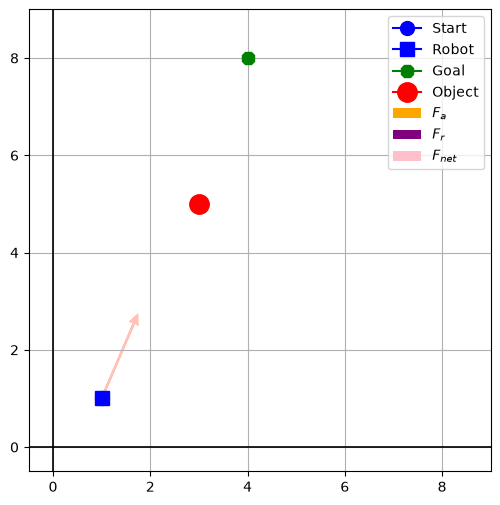

In [18]:
plt.figure(figsize=(6, 6))


plt.plot(initial[0], initial[1], 
         color='blue', marker='o', linestyle='-', markersize=10,
         label='Start')
plt.plot(robot[0], robot[1], 
         color='blue', marker='s', linestyle='-', markersize=10,
         label='Robot')
plt.plot(goal[0], goal[1], 
         color='green', marker='8', linestyle='-', markersize=10,
         label='Goal')
plt.plot(obj[0], obj[1], 
         color='red', marker='o', linestyle='-', markersize=14 ,
         label='Object')

# Plot the 3 matching vectors
plt.quiver(robot[0], robot[1], F_a[0], F_a[1], color='orange', label=r'$F_a$',
           angles='xy', scale_units='xy', scale=1, width=0.005, headwidth=4.5, headlength=5)

plt.quiver(robot[0], robot[1], F_r[0], F_r[1], color='purple', label=r'$F_r$',
           angles='xy', scale_units='xy', scale=1, width=0.005, headwidth=4.5, headlength=5)

plt.quiver(robot[0], robot[1], F[0], F[1], color='pink', label=r'$F_{net}$',
           angles='xy', scale_units='xy', scale=1, width=0.005, headwidth=4.5, headlength=5)

plt.legend()

# Set your view limits so (0,0) is in the bottom-left and everything fits
plt.xlim(-0.5, 9)
plt.ylim(-0.5, 9)

# Formatting
plt.grid(True)
plt.axhline(0, color='black', linewidth=1.2)
plt.axvline(0, color='black', linewidth=1.2)
plt.gca().set_aspect('equal')
plt.legend()

# plt.show()

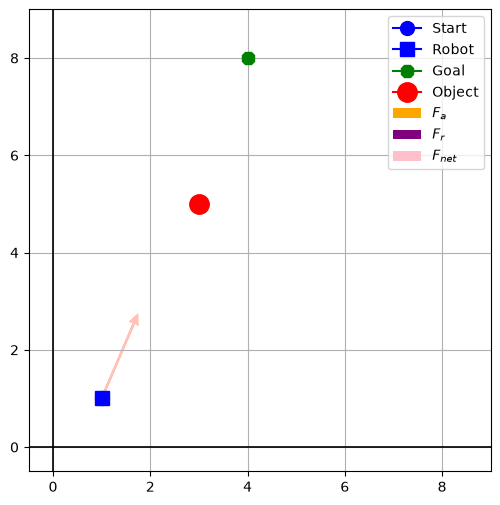

In [19]:
plt.figure(figsize=(6, 6))


plt.plot(initial[0], initial[1], 
         color='blue', marker='o', linestyle='-', markersize=10,
         label='Start')
plt.plot(robot[0], robot[1], 
         color='blue', marker='s', linestyle='-', markersize=10,
         label='Robot')
plt.plot(goal[0], goal[1], 
         color='green', marker='8', linestyle='-', markersize=10,
         label='Goal')
plt.plot(obj[0], obj[1], 
         color='red', marker='o', linestyle='-', markersize=14 ,
         label='Object')

# Plot the 3 matching vectors
plt.quiver(robot[0], robot[1], F_a[0], F_a[1], color='orange', label=r'$F_a$',
           angles='xy', scale_units='xy', scale=1, width=0.005, headwidth=4.5, headlength=5)

plt.quiver(robot[0], robot[1], F_r[0], F_r[1], color='purple', label=r'$F_r$',
           angles='xy', scale_units='xy', scale=1, width=0.005, headwidth=4.5, headlength=5)

plt.quiver(robot[0], robot[1], F[0], F[1], color='pink', label=r'$F_{net}$',
           angles='xy', scale_units='xy', scale=1, width=0.005, headwidth=4.5, headlength=5)

plt.legend()

# Set your view limits so (0,0) is in the bottom-left and everything fits
plt.xlim(-0.5, 9)
plt.ylim(-0.5, 9)

# Formatting
plt.grid(True)
plt.axhline(0, color='black', linewidth=1.2)
plt.axvline(0, color='black', linewidth=1.2)
plt.gca().set_aspect('equal')
plt.legend()

plt.show()